# House Prices Prediction

Proyecto de análisis exploratorio y predicción de precios de viviendas usando Python.

El objetivo es construir un modelo de machine learning capaz de predecir el precio de venta de una vivienda a partir de sus características.
A lo largo del código, se han añadido comentarios para guiar al lector en el tren de pensamientos del autor.

## Tecnologías utilizadas

- Python
- pandas
- NumPy
- matplotlib
- scikit-learn

## Cronología del proyecto

1. Carga y exploración inicial de datos.
2. Limpieza y preparación de datos.
3. Análisis exploratorio de datos.
4. Modelado.
5. Análisis de importancia de variables.
6. Conclusiones.

In [1]:
# Importación de librerías

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

## 1. Carga de datos y exploración inicial

En esta sección se carga el dataset y se realiza una primera exploración para conocer su estructura y valores disponibles.

In [2]:
df = pd.read_csv("train.csv")

print(df.head())
df.info()
print(df.isnull().sum().sort_values(ascending=False))

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

## 2. Limpieza y preparación de datos

Se tratan los valores nulos teniendo en cuenta el significado de cada variable. Algunas columnas con muchos valores nulos representan la ausencia de una característica, como piscina, chimenea, garaje o sótano.

In [3]:
#La ausencia de PoolQC probablemente indique que la casa no tiene piscina. Por ello vamos a sustituirla con una columna Pool que será una variable binaria

df["Pool"] = df["PoolQC"].notnull().astype(int)
df = df.drop("PoolQC", axis=1)

#Al ser variables no muy importantes en el precio de una casa y estar la mayor parte de ellas vacías, las vamos a quitar.
df = df.drop(["Fence", "Alley"], axis=1)
df = df.drop("MiscFeature", axis=1)

df["MasVnrType"] = df["MasVnrType"].fillna("None")

print(df.isnull().sum().sort_values(ascending=False).head(20))

#Con Fireplace procedemos igual que con Pool:
df["Fireplace"] = df["FireplaceQu"].notnull().astype(int)
df = df.drop("FireplaceQu", axis=1)

#La ausencia de esta variable ya no indica que no tenga tal característica, ya que muchas casas tienen algún tipo de espacio frontal.
#Por ello, la vamos a rellenar con la mediana, que no sufre tanto con valores atípicamente altos:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

#La ausencia de datos en las características de garaje, al coincidir todas en número, muy probablemente quiere decir que no tienen
#garaje. Las rellenaremos con None:
df["GarageType"] = df["GarageType"].fillna("None")
df["GarageQual"] = df["GarageQual"].fillna("None")
df["GarageFinish"] = df["GarageFinish"].fillna("None")
df["GarageCond"] = df["GarageCond"].fillna("None")
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

#Igual con Bsmt:
df["BsmtFinType2"] = df["BsmtFinType2"].fillna("None")
df["BsmtFinType1"] = df["BsmtFinType1"].fillna("None")
df["BsmtExposure"] = df["BsmtExposure"].fillna("None")
df["BsmtQual"] = df["BsmtQual"].fillna("None")
df["BsmtCond"] = df["BsmtCond"].fillna("None")

#La ausencia de MasVnrArea probablemente se debe a que no tiene una fachada especial, lo rellenamos con 0.
#Respecto a Electrical, es algo raro que una casa no tenga electricidad, así que simplemente ponemos la moda de esta variable.
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

print(df.isnull().sum().sort_values(ascending=False).head(20))

FireplaceQu     690
LotFrontage     259
GarageCond       81
GarageType       81
GarageFinish     81
GarageQual       81
GarageYrBlt      81
BsmtExposure     38
BsmtFinType2     38
BsmtQual         37
BsmtCond         37
BsmtFinType1     37
MasVnrArea        8
Electrical        1
KitchenAbvGr      0
BedroomAbvGr      0
HalfBath          0
BsmtHalfBath      0
BsmtFullBath      0
KitchenQual       0
dtype: int64
Id              0
HalfBath        0
GarageType      0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
KitchenQual     0
KitchenAbvGr    0
BedroomAbvGr    0
FullBath        0
GarageFinish    0
BsmtHalfBath    0
BsmtFullBath    0
GrLivArea       0
LowQualFinSF    0
2ndFlrSF        0
1stFlrSF        0
Electrical      0
GarageYrBlt     0
GarageCars      0
dtype: int64


## 3. Análisis exploratorio de datos

En esta sección se analiza la variable objetivo `SalePrice` y su relación con algunas de las variables más relevantes del dataset.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


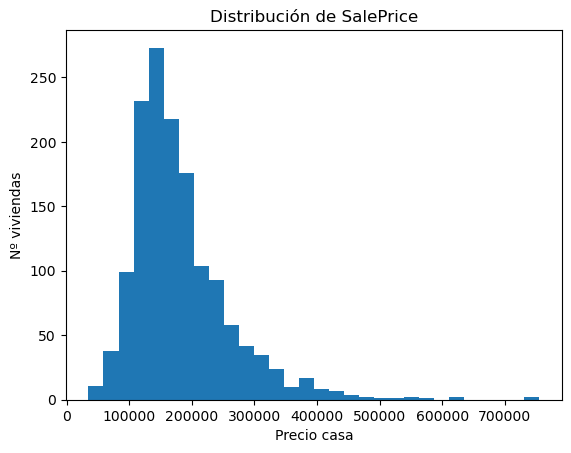

In [5]:
print(df["SalePrice"].describe()) #obtenemos pinceladas generales de la variable objetivo.

#Vamos a ver qué forma tiene la distribución de la variable objetivo:
plt.figure('Distribución precios viviendas')
plt.hist(df["SalePrice"], bins=30)
plt.title('Distribución de SalePrice')
plt.xlabel("Precio casa")
plt.ylabel("Nº viviendas")
plt.show()

En el gráfico obtenido, podemos ver que la distribución de SalePrice tiene una gran concentración en valores medios. También
destacar que tiene una cola más larga a la derecha y con valores más alejados de la concentracion principal de casas
esto quiere decir que la distribucion tiene un sesgo positivo (hacia la derecha). Además, hay varios valores muy alejados
de los centrales. Esto nos muestra que la distribución tiene varios outliers.

### Correlaciones con la variable objetivo

Se calculan las correlaciones entre las variables numéricas y `SalePrice` para identificar qué características tienen una mayor relación lineal con el precio de venta. Tmabién "enfrentamos" en algunos gráficos las variables con más correlación con la variable objetivo.

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplace        0.471908
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
GarageYrBlt      0.261366
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
Pool             0.093708
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorc

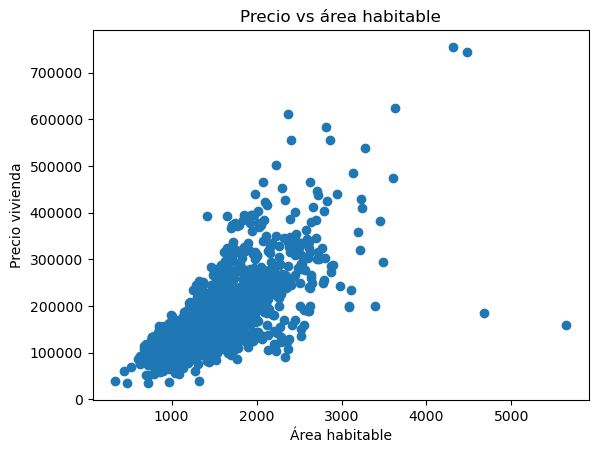

In [6]:
corr = df.corr(numeric_only=True)
print(corr["SalePrice"].sort_values(ascending=False))


plt.figure('Precio vs área habitable')
plt.scatter(df["GrLivArea"], df["SalePrice"])
plt.title('Precio vs área habitable')
plt.xlabel('Área habitable')
plt.ylabel('Precio vivienda')
plt.show()

De este gráfico podemos observar que, como podíamos anticipar, hay una clara relación positiva entre el área y el precio
Además, para valores centrales del área, se puede observar que la relación es aproximadamente lineal y bastante estable.
Sin embargo, hay outliers de todo tipo: casas con área muy grande pero precio ridículamente bajo y casas con un precio
demasiado elevado para su área.
De todo esto obtenemos que el área habitable es una variable muy importante, pero no suficiente para determinar el precio

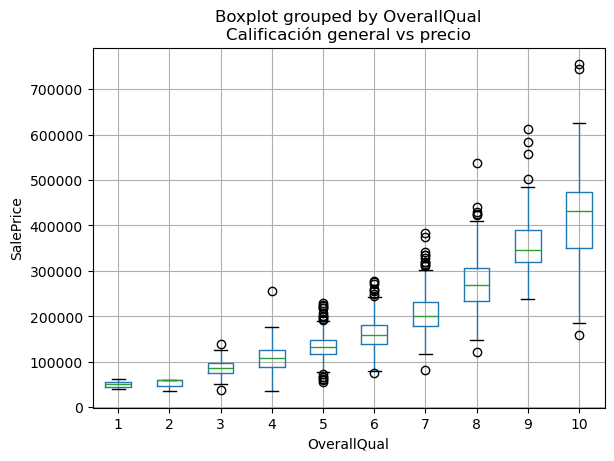

In [9]:
#Procedemos igual, pero con la variable OverallQual y esta vez con un boxplot, más adecuado a una variable discreta:
df.boxplot(column="SalePrice", by="OverallQual")
plt.title('Calificación general vs precio')
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.show()

Observamos que en general la variable valoración general, si nos da una buena idea orientativa del precio.
Esto se puede apreciar viendo que medianas y cajas aumentan paulatinamente conforme aumenta la valoración general. Sin embargo,
hay que resaltar que solo sirve como orientación, ya que, sobre todo en los valores centrales, hay muchos outliers que salen
de los bigotes y las cajas con el 50% de datos son bastante amplias.

Vamos a complementar esto con una variable categórica fuerte, como puede ser `Neighborhood` :

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


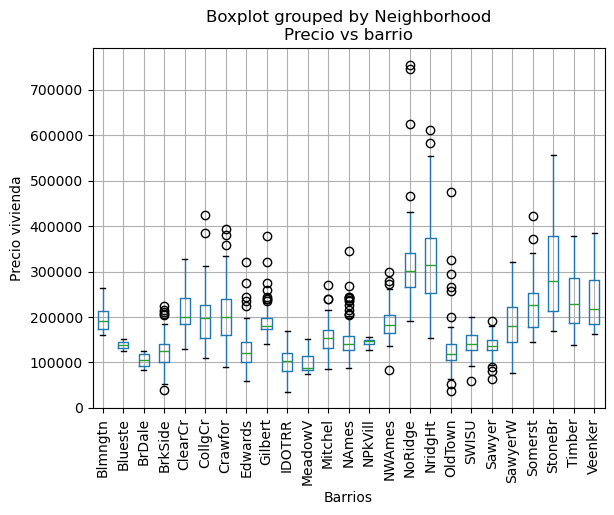

In [10]:
#Vemos la media de precio de los barrios, para tener una primera idea:
print(df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False))

df.boxplot(column="SalePrice", by="Neighborhood")
plt.title('Precio vs barrio')
plt.xlabel('Barrios')
plt.ylabel('Precio vivienda')
plt.xticks(rotation=90)
plt.show()

En este gráfico, podemos ver que hay cajas y medianas con grandes diferencias de precio, lo cual nos dice que potencialmente puede ser
una variable que nos dé mucha información.

## 4. Modelado

En esta sección se preparan las variables predictoras y la variable objetivo. Posteriormente se entrenan dos modelos: una regresión lineal y un Random Forest Regressor.

Primero se separa `SalePrice`, que será la variable objetivo, del resto de variables del dataset.

In [11]:
x = df.drop(["SalePrice"], axis=1)
y = df["SalePrice"]

x = pd.get_dummies(x, drop_first=True) #Hemos hecho one-hot encoding a las variables categóricas para poder tratarlas.

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

Como punto de partida empezamos con una regresión lineal. Esto nos sirve para ver si existiera una cierta relación lineal entre las variables predictoras y la objetivo. Incluimos las métricas resultado del model y gráfico.

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Resultados con modelo lineal:')
print("MAE =", mae)
print('RMSE = ', rmse)
print('R^2 =', r2)

plt.figure('Regresión lineal')
plt.scatter(y_test, y_pred, label=f"R^2 = {r2:.3f}")
plt.title('Regresión lineal')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.legend()
plt.show()

En los resultados podemos observar que, debido a la diferencia entre el mae y el rmse, hay errores muy grandes que están
bajando la calidad del modelado. Además, el R2 es de 0.59 que es muy bajo.
El gráfico muestra que para precios medios-bajos, el modelo lineal capta razonablemente bien la tendencia de precios. Sin embargo,
en precios medios-altos, la dispersión aumenta mucho más, además de que hay outliers con diferencias entre el precio real y predicho enormes.
Esto nos lleva a remodelar con Random Forest.

Resultados con Random Forest:
MAE = 17743.754520547947
RMSE =  34552.780604338084
R^2 = 0.8271183628786254


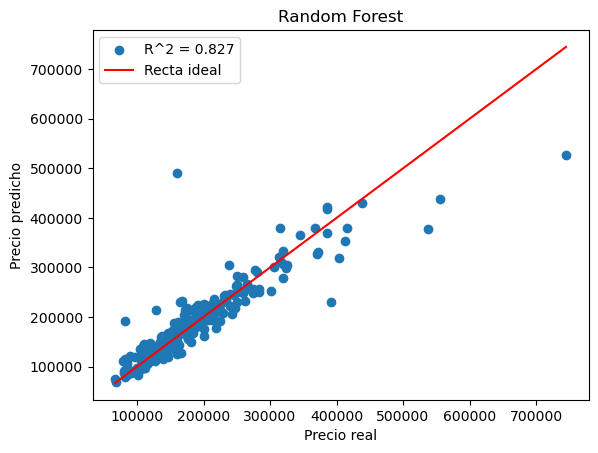

In [16]:
rf_model = RandomForestRegressor(random_state=0)
rf_model.fit(x_train, y_train)
yrf_pred = rf_model.predict(x_test)

mae_rf = mean_absolute_error(y_test, yrf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, yrf_pred))
r2_rf = r2_score(y_test, yrf_pred)

print('Resultados con Random Forest:')
print("MAE =", mae_rf)
print('RMSE = ', rmse_rf)
print('R^2 =', r2_rf)

plt.figure('Random Forest')
plt.scatter(y_test, yrf_pred, label=f"R^2 = {r2_rf:.3f}")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    label="Recta ideal"
)
plt.title('Random Forest')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.legend()
plt.show()

Estos ya son valores más aceptables. Nos fijamos en que el rmse ha bajado considerablemente. Esto nos dice que los errores
tan grandes que cometía el modelo lineal son razonablemente corregidos por este nuevo modelo.
Aunque también hay una bajada en el mae, el mayor cambio es el aumento del R^2. El R^2 obtenido ya es considerable para un buen
modelo.
Con este gráfico terminamos la conclusión de Random Forest diciendo que muestra un ajuste bastante bueno en precios medios-bajos.
Sin embargo, en precios más altos, el modelo parece tener tendencia a infrapredecir, ya que hay bastantes más puntos debajo de
la recta ideal. Aunque siguen existiendo outliers llamativos, ya vimos con la bajada del rmse que el modelo mejora bastante
en errores grandes, y también lo hace en general.

## 5. Importancia de variables

En caso de que se quisiera construir un modelo más complejo o interpretar mejor el comportamiento del Random Forest, se puede estudiar la importancia de las variables utilizadas por el modelo.

In [17]:
importancia = rf_model.feature_importances_
importancia_df = pd.DataFrame({
    "Variable": x_train.columns,
    "Importancia": importancia
})
importancia_df = importancia_df.sort_values(by="Importancia", ascending=False)

print('Las variables con más importancia son:')
print(importancia_df.head(10))

Las variables con más importancia son:
       Variable  Importancia
4   OverallQual     0.577386
16    GrLivArea     0.122222
12  TotalBsmtSF     0.043537
9    BsmtFinSF1     0.029215
27   GarageArea     0.022211
13     1stFlrSF     0.019877
26   GarageCars     0.014814
8    MasVnrArea     0.013736
3       LotArea     0.013364
14     2ndFlrSF     0.013328


## 6. Conclusiones

En este proyecto se ha desarrollado un proceso completo de machine learning para predecir precios de viviendas.

Primero se realizó una limpieza de datos, tratando valores nulos y creando nuevas variables binarias para representar características. Después se llevó a cabo un análisis exploratorio de datos para estudiar la distribución de los precios y su relación con variables relevantes como la superficie habitable, la calidad general y el barrio.

En la fase de modelado se compararon dos enfoques: una regresión lineal y un Random Forest Regressor. La regresión lineal sirvió como modelo base, pero mostró limitaciones importantes, especialmente a partir de viviendas con precios medio-altos y con errores grandes.

El modelo Random Forest obtuvo mejores resultados, reduciendo los errores y aumentando el R². Además, permitió analizar la importancia de las variables, lo que ayuda a interpretar qué características tienen más peso en la predicción del precio.

Como siguientes mejoras, se podrían probar técnicas de validación cruzada, optimización de hiperparámetros, tratamiento de outliers y modelos más avanzados como Gradient Boosting o XGBoost.